In [7]:
import zipfile


zip_path = 'bank-data.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('dataset_bank')

print("Bank Dataset Unzipped Successfully!")

Bank Dataset Unzipped Successfully!


In [8]:
import os
import pandas as pd


csv_file = None
for root, dirs, files in os.walk('dataset_bank'):
    if '__MACOSX' in root:
        continue
    for file in files:
        if file.endswith('.csv') and not file.startswith('._'):
            csv_file = os.path.join(root, file)
            break

print("Found CSV File Path:", csv_file)


df = pd.read_csv(csv_file, sep=';')
print("Dataset Shape:", df.shape)
df.head()

Found CSV File Path: dataset_bank/bank-data/bank-full.csv
Dataset Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


df['y'] = df['y'].map({'yes': 1, 'no': 0})


categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


X = df_encoded.drop('y', axis=1)
y = df_encoded['y']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing & Scaling Completed Successfully!")

Data Preprocessing & Scaling Completed Successfully!


Accuracy Score: 90.12%

--- Classification Report ---
              precision    recall  f1-score   support

          No       0.92      0.97      0.95      7985
         Yes       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



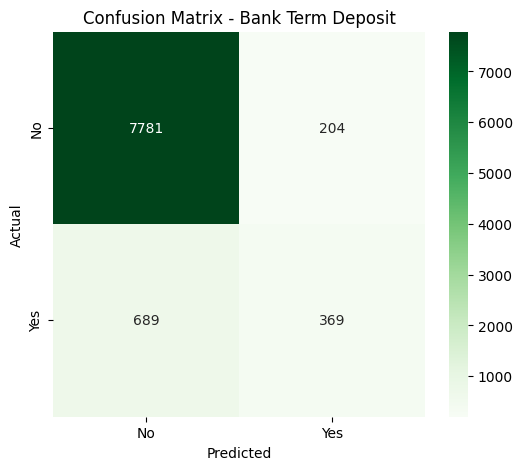

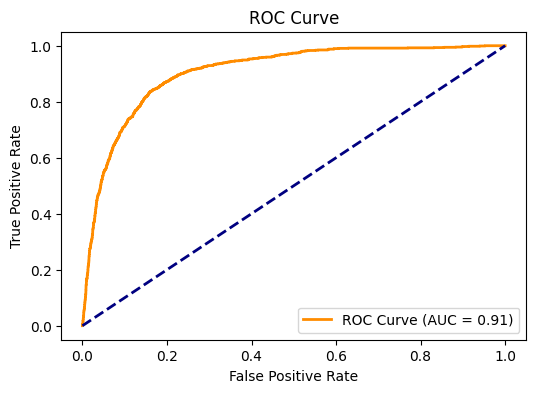

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve


model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]


print(f"Accuracy Score: {accuracy_score(y_test, y_pred)*100:.2f}%\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Bank Term Deposit')
plt.show()


fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()